# importing library

In [1]:

import numpy as np 
import pandas as pd 


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub


/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/clinical_trials.csv
/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/biotech_funding.csv
/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/pharma_companies_financials.csv
/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/drug_approvals.csv
/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/disease_burden.csv


# loading datasets

In [2]:
clin_trial=pd.read_csv("/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/clinical_trials.csv")
bio_fund=pd.read_csv("/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/biotech_funding.csv")
phar_cmpny=pd.read_csv("/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/pharma_companies_financials.csv")
drug_approv=pd.read_csv("/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/drug_approvals.csv")
dis_burdn=pd.read_csv("/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/disease_burden.csv")




dset={
    "clin":clin_trial,
    "bio":bio_fund,
    "phar":phar_cmpny,
    "drug":drug_approv,
    "dis":dis_burdn
}

for name,df in dset.items():
    print(name)
    print(df.columns.to_list())

clin
['trial_id', 'completion_date', 'year', 'sponsor', 'therapy_area', 'phase', 'enrollment_n', 'duration_months', 'outcome', 'is_success', 'is_failure', 'estimated_stock_impact_pct']
bio
['deal_id', 'date', 'year', 'deal_type', 'acquirer_or_investors', 'target_or_company', 'value_usd_bn', 'description', 'is_megadeal', 'is_real_headline']
phar
['year', 'company_name', 'ticker', 'country_iso3', 'segment', 'revenue_usd_bn', 'operating_margin_pct', 'operating_income_usd_bn', 'rd_spend_usd_bn', 'pipeline_size_est']
drug
['approval_id', 'approval_date', 'year', 'drug_name', 'sponsor_company', 'drug_type', 'therapy_area', 'peak_sales_usd_bn_est', 'is_blockbuster', 'is_mega_blockbuster', 'description', 'is_real_headline']
dis
['year', 'region', 'disease', 'dalys_millions', 'global_dalys_millions']


# convert date columns to datetime

In [3]:
drug_approv['approval_date']=pd.to_datetime(drug_approv['approval_date'],errors='coerce')
bio_fund['date']=pd.to_datetime(bio_fund['date'],errors='coerce')
clin_trial['completion_date']=pd.to_datetime(clin_trial['completion_date'],errors="coerce")







# preprocessing step
# counting null values 

In [4]:
for name,df in dset.items():
    print(f"{name} ")
    print(df.isnull().sum())



clin 
trial_id                      0
completion_date               0
year                          0
sponsor                       0
therapy_area                  0
phase                         0
enrollment_n                  0
duration_months               0
outcome                       0
is_success                    0
is_failure                    0
estimated_stock_impact_pct    0
dtype: int64
bio 
deal_id                  0
date                     0
year                     0
deal_type                0
acquirer_or_investors    0
target_or_company        0
value_usd_bn             0
description              0
is_megadeal              0
is_real_headline         0
dtype: int64
phar 
year                       0
company_name               0
ticker                     0
country_iso3               0
segment                    0
revenue_usd_bn             0
operating_margin_pct       0
operating_income_usd_bn    0
rd_spend_usd_bn            0
pipeline_size_est          0
dtype: int64


# cheacking duplicate values

In [5]:
for name,df in dset.items():
    print(f"{name}")
    print(df.duplicated().sum())
    

clin
0
bio
0
phar
0
drug
0
dis
0


In [6]:
#printing the shapes of every datasets
for name,df in dset.items():
    print(f"{name}")
    print(df.shape)

clin
(599, 12)
bio
(1208, 10)
phar
(489, 10)
drug
(722, 12)
dis
(3310, 5)


# description of every datasets

In [7]:
for name,df in dset.items():
    print(f"{name}")
    print(df.describe())

clin
                     completion_date         year  enrollment_n  \
count                            599   599.000000    599.000000   
mean   2018-02-06 13:10:55.091819776  2017.612688    790.163606   
min              2010-01-05 00:00:00  2010.000000     47.000000   
25%              2013-10-04 12:00:00  2013.000000    244.500000   
50%              2018-02-12 00:00:00  2018.000000    524.000000   
75%              2022-05-25 00:00:00  2022.000000   1112.000000   
max              2026-04-05 00:00:00  2026.000000   4179.000000   
std                              NaN     4.759807    720.689342   

       duration_months  is_success  is_failure  estimated_stock_impact_pct  
count       599.000000  599.000000  599.000000                  599.000000  
mean         27.555927    0.520868    0.325543                   -0.961436  
min           6.000000    0.000000    0.000000                  -41.200000  
25%          18.000000    0.000000    0.000000                   -8.550000  
50%   

# information of every dataset

In [8]:
for name,df in dset.items():
    print(f"{name}")
    print(df.info())

clin
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   trial_id                    599 non-null    object        
 1   completion_date             599 non-null    datetime64[ns]
 2   year                        599 non-null    int64         
 3   sponsor                     599 non-null    object        
 4   therapy_area                599 non-null    object        
 5   phase                       599 non-null    object        
 6   enrollment_n                599 non-null    int64         
 7   duration_months             599 non-null    int64         
 8   outcome                     599 non-null    object        
 9   is_success                  599 non-null    int64         
 10  is_failure                  599 non-null    int64         
 11  estimated_stock_impact_pct  599 non-null    float64  

In [9]:
for name,df in dset.items():
    print(f"{name}********************************")
    print(df.nunique())
    

clin********************************
trial_id                      599
completion_date               574
year                           17
sponsor                        21
therapy_area                   10
phase                           2
enrollment_n                  485
duration_months                47
outcome                         3
is_success                      2
is_failure                      2
estimated_stock_impact_pct    328
dtype: int64
bio********************************
deal_id                  1208
date                     1053
year                       18
deal_type                   6
acquirer_or_investors      34
target_or_company        1083
value_usd_bn              632
description               125
is_megadeal                 2
is_real_headline            2
dtype: int64
phar********************************
year                        17
company_name                30
ticker                      30
country_iso3                10
segment                      6
r

# importing important library for visualization

In [10]:
import matplotlib.pyplot as plt
plt.switch_backend('Agg')
%matplotlib inline
import seaborn as sns

# EDA 

# DISTRIBUTION OF IMPORTANT COLUMNS

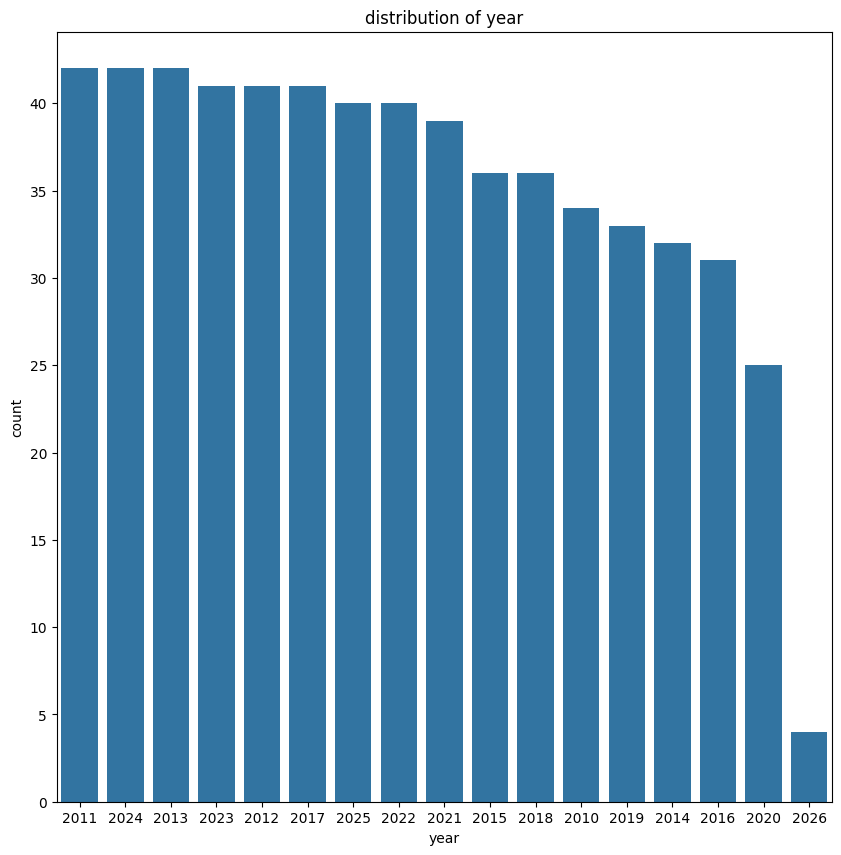

In [11]:
#distribution of year
plt.figure(figsize=(10,10))
sns.countplot(data=clin_trial,x='year',order=clin_trial['year'].value_counts().index)
plt.title("distribution of year")
plt.show()

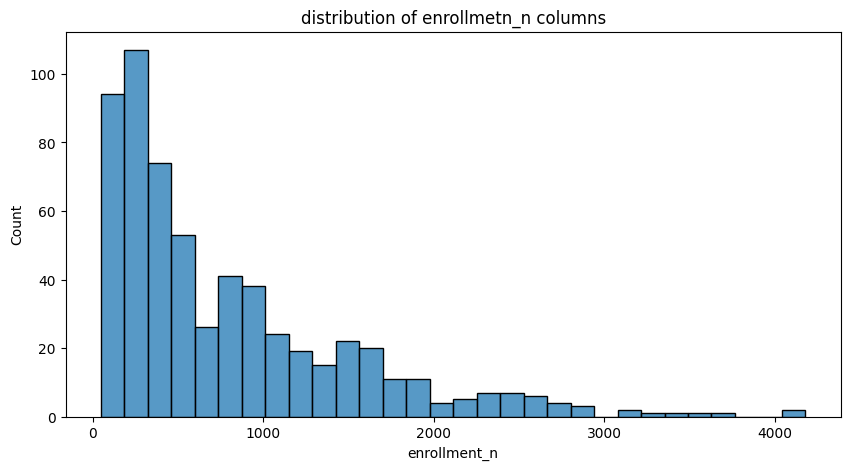

In [12]:
plt.figure(figsize=(10,5))
sns.histplot(data=clin_trial,x='enrollment_n',bins=30)
plt.title("distribution of enrollmetn_n columns")
plt.show()

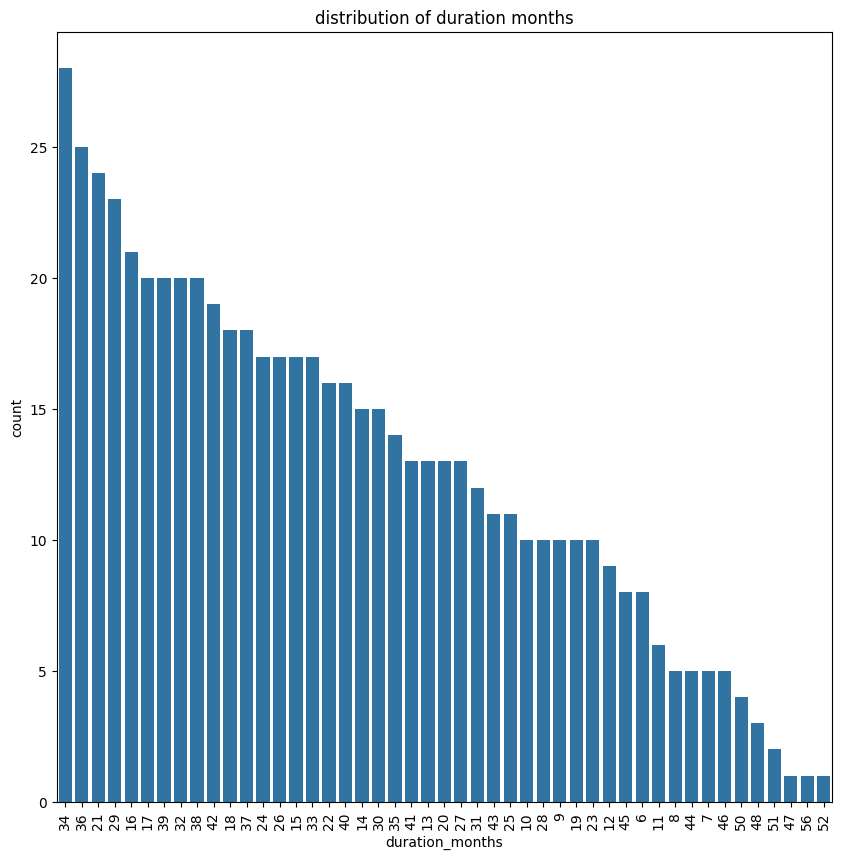

In [13]:
plt.figure(figsize=(10,10))
sns.countplot(data=clin_trial,x='duration_months',order=clin_trial['duration_months'].value_counts().index)
plt.title("distribution of duration months")
plt.xticks(rotation=90)
plt.show()

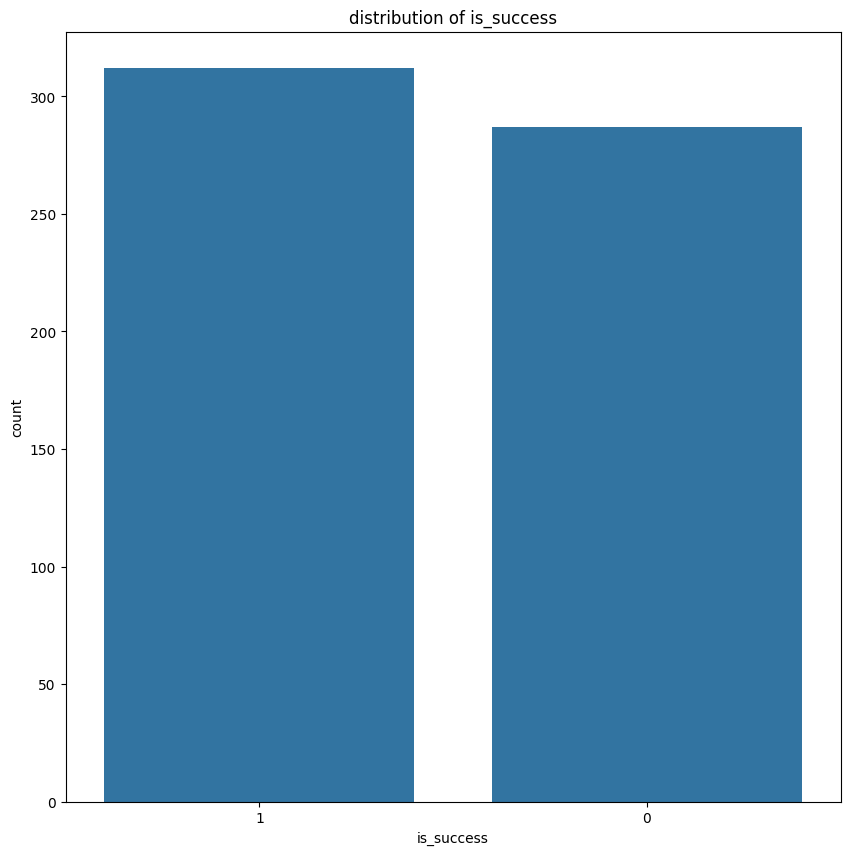

In [14]:
#distribution of is success
plt.figure(figsize=(10,10))
sns.countplot(data=clin_trial,x='is_success',order=clin_trial['is_success'].value_counts().index)
plt.title("distribution of is_success")
plt.show()

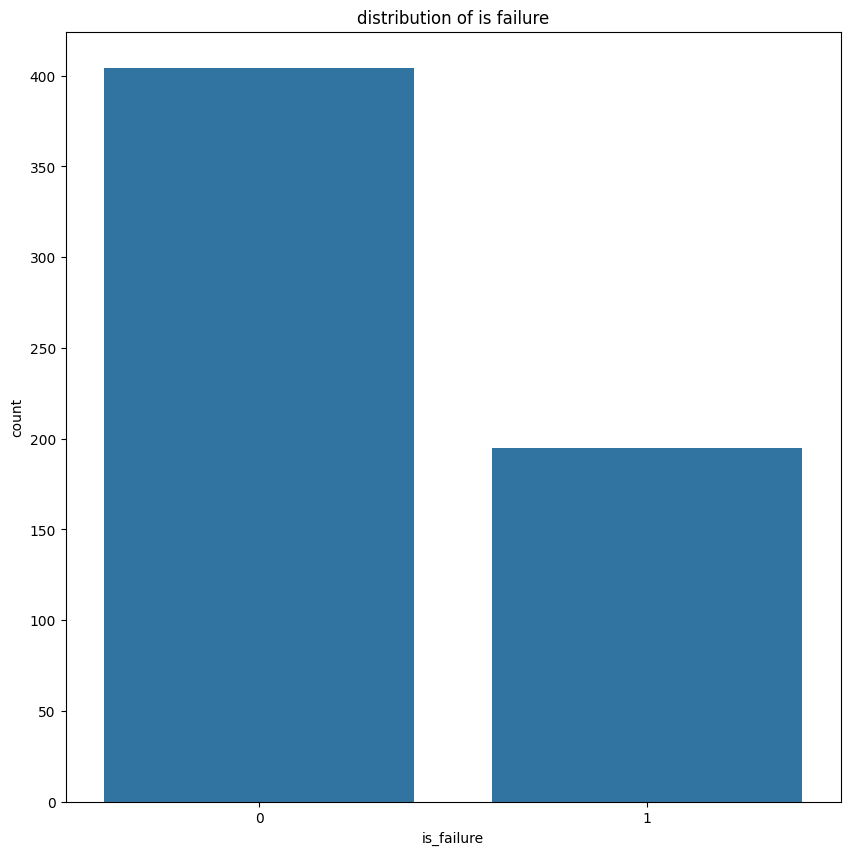

In [15]:
plt.figure(figsize=(10,10))
sns.countplot(data=clin_trial,x='is_failure',order=clin_trial['is_failure'].value_counts().index)
plt.title("distribution of is failure")
plt.show()


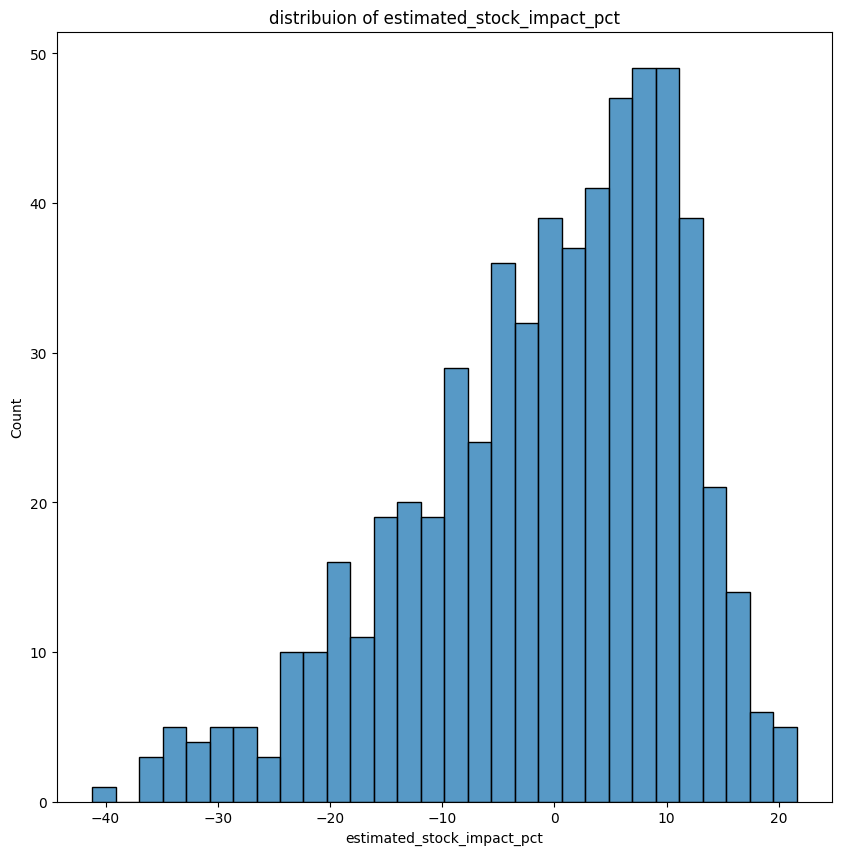

In [16]:
plt.figure(figsize=(10,10))
sns.histplot(data=clin_trial,x='estimated_stock_impact_pct',bins=30)
plt.title("distribuion of estimated_stock_impact_pct")
plt.show()

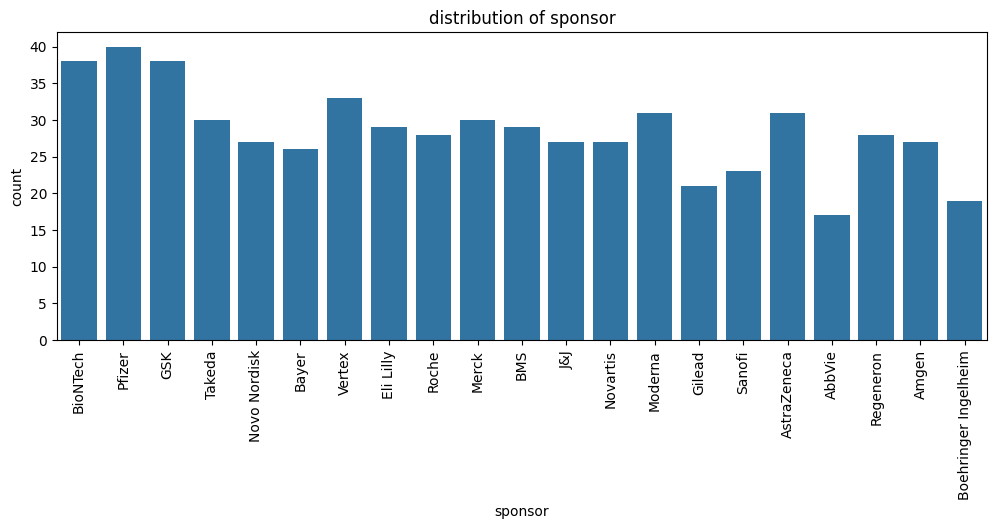

In [17]:
plt.figure(figsize=(12,4))
sns.countplot(data=clin_trial,x='sponsor')
plt.title("distribution of sponsor")

plt.xticks(rotation=90)
plt.show()

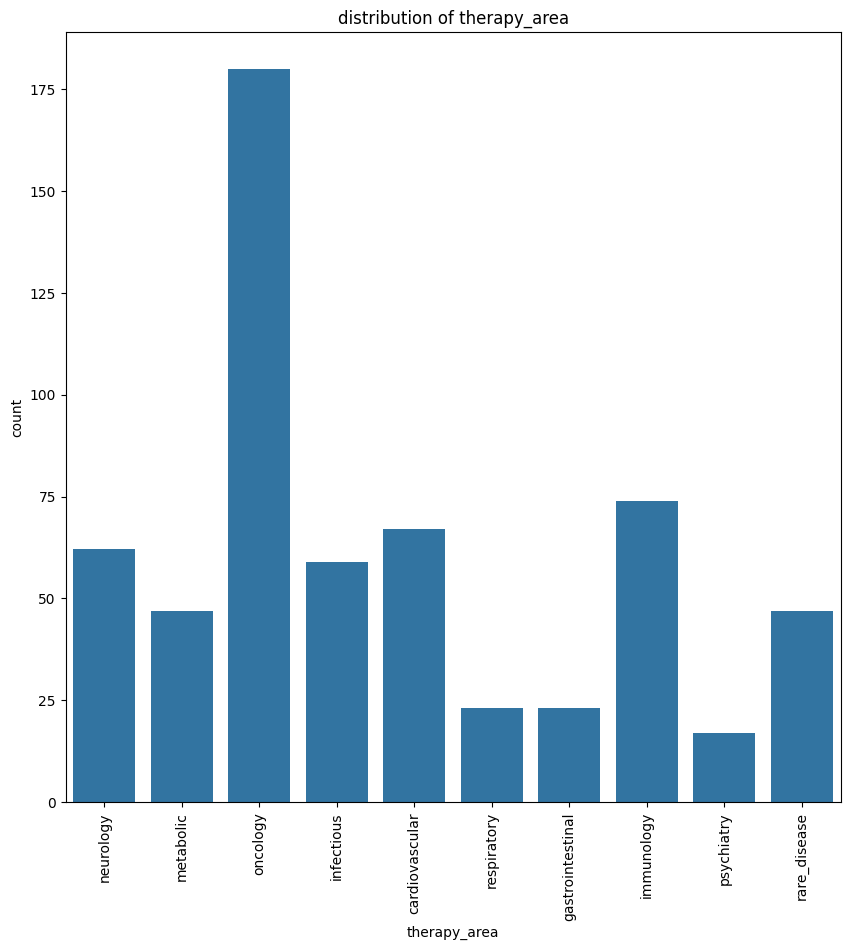

In [18]:
plt.figure(figsize=(10,10))
sns.countplot(data=clin_trial,x='therapy_area')
plt.title("distribution of therapy_area")
plt.xticks(rotation=90)
plt.show()

In [19]:
clin_trial.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   trial_id                    599 non-null    object        
 1   completion_date             599 non-null    datetime64[ns]
 2   year                        599 non-null    int64         
 3   sponsor                     599 non-null    object        
 4   therapy_area                599 non-null    object        
 5   phase                       599 non-null    object        
 6   enrollment_n                599 non-null    int64         
 7   duration_months             599 non-null    int64         
 8   outcome                     599 non-null    object        
 9   is_success                  599 non-null    int64         
 10  is_failure                  599 non-null    int64         
 11  estimated_stock_impact_pct  599 non-null    float64       

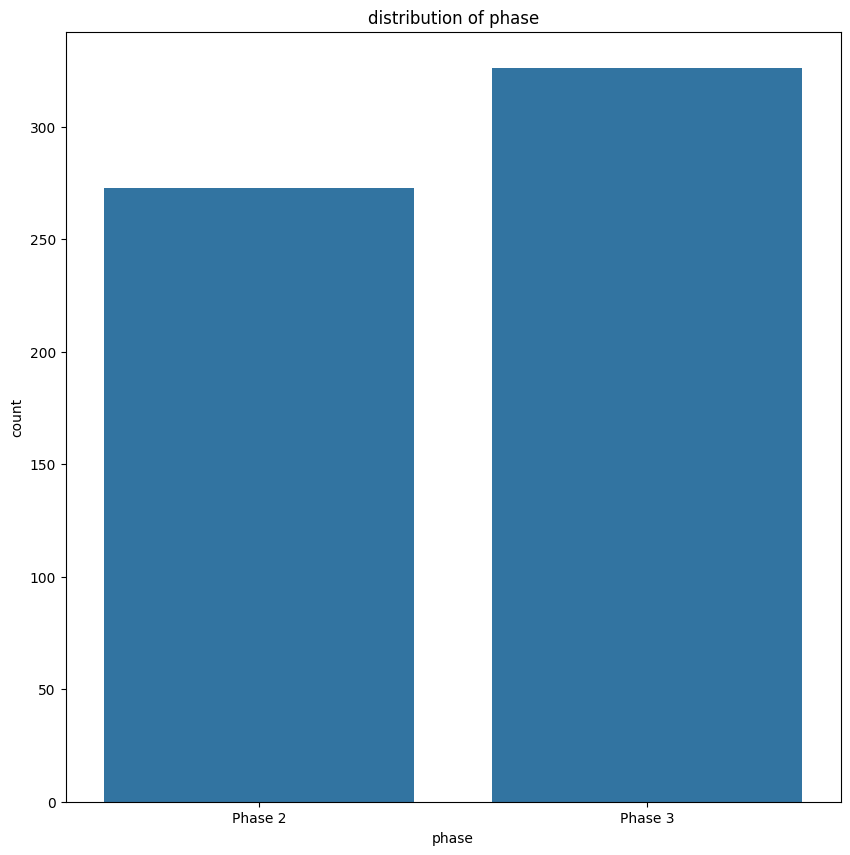

In [20]:
plt.figure(figsize=(10,10))
sns.countplot(data=clin_trial,x='phase')
plt.title("distribution of phase")
plt.show()

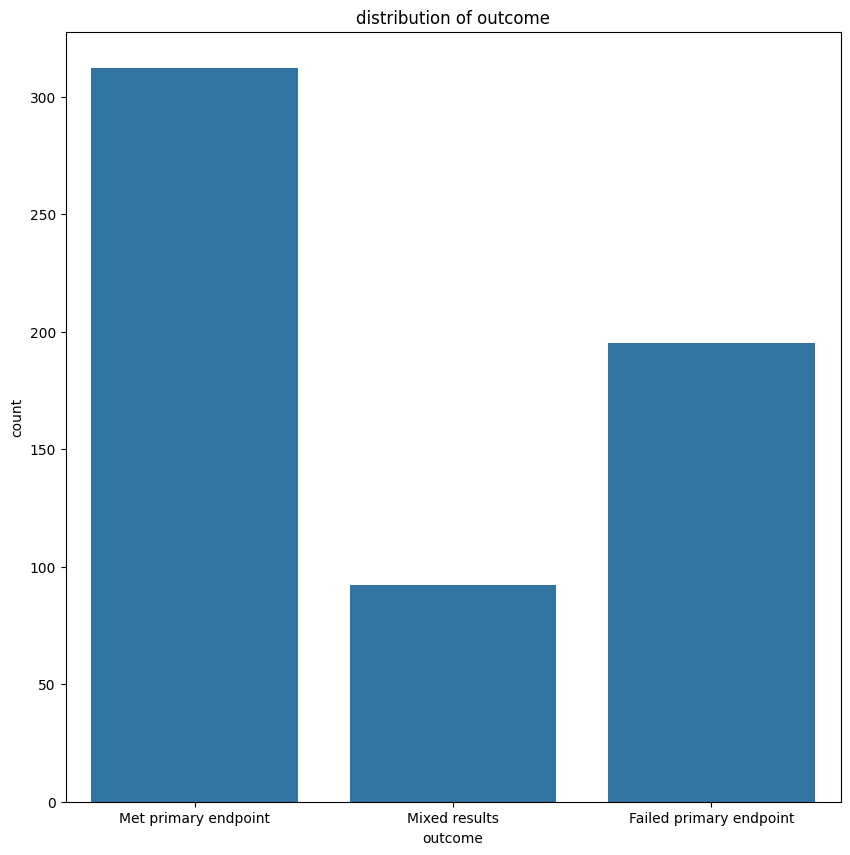

In [21]:
plt.figure(figsize=(10,10))
sns.countplot(data=clin_trial,x='outcome')
plt.title("distribution of outcome")
plt.show()

# CORRELATION

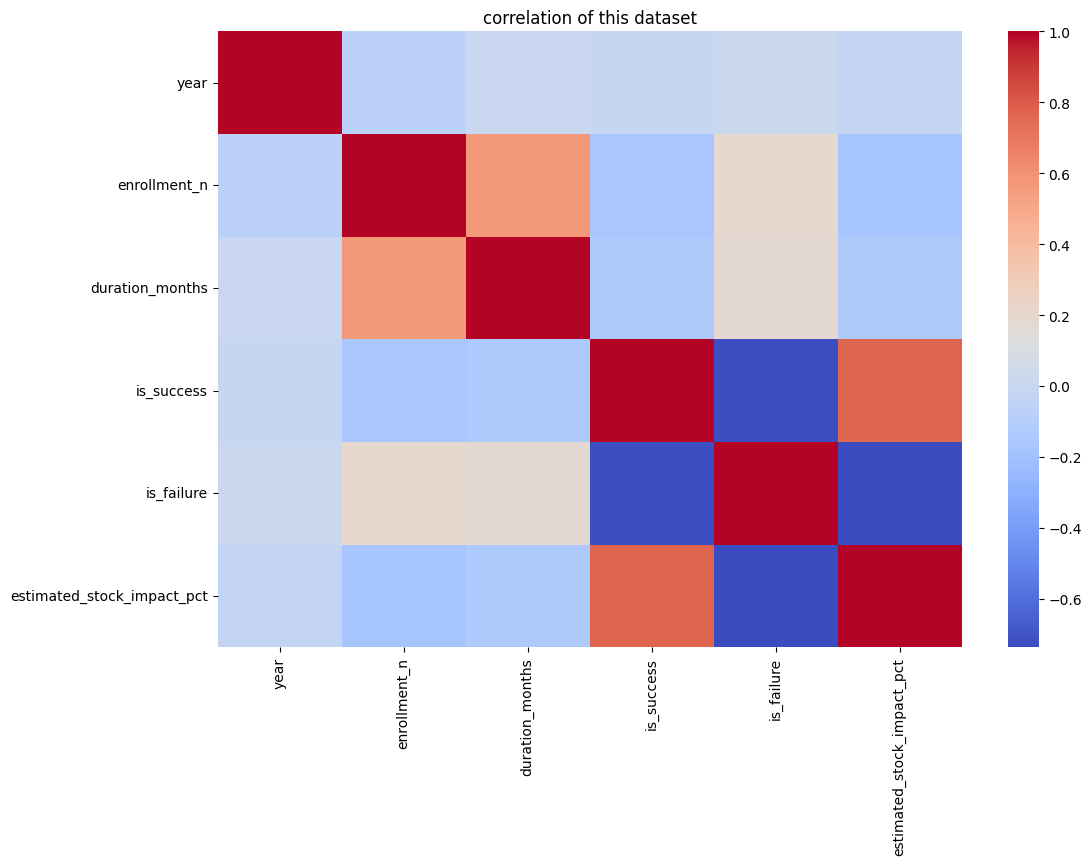

In [22]:
numeric=clin_trial.select_dtypes(include="number")
corr=numeric.corr(method="pearson")
plt.figure(figsize=(12,8))
sns.heatmap(corr,annot=False,cmap="coolwarm",fmt=".2f")
plt.title("correlation of this dataset")
plt.show()

In [23]:
df=clin_trial
df.columns

Index(['trial_id', 'completion_date', 'year', 'sponsor', 'therapy_area',
       'phase', 'enrollment_n', 'duration_months', 'outcome', 'is_success',
       'is_failure', 'estimated_stock_impact_pct'],
      dtype='object')

# RElATION BETWEEN IMPORTANTS COLUMN AND TARGET COLUMN

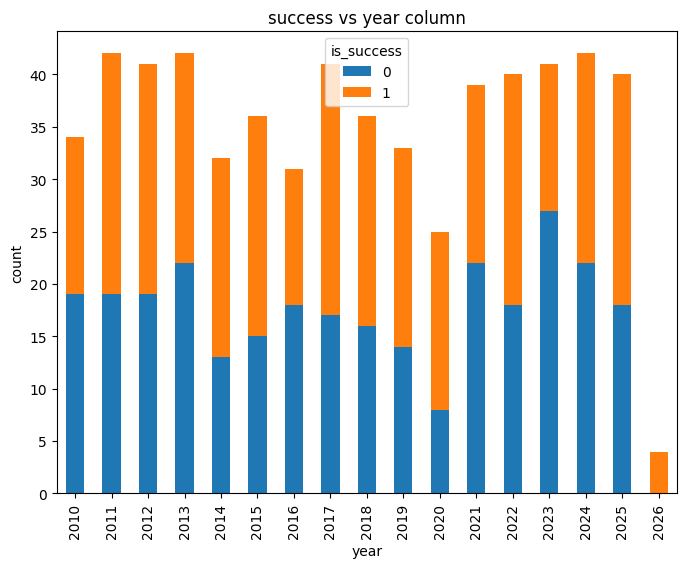

In [24]:
ct=pd.crosstab(df['year'],df['is_success'])
ct.plot(kind="bar",stacked=True,figsize=(8,6))
plt.title("success vs year column")
plt.ylabel("count")
plt.show()

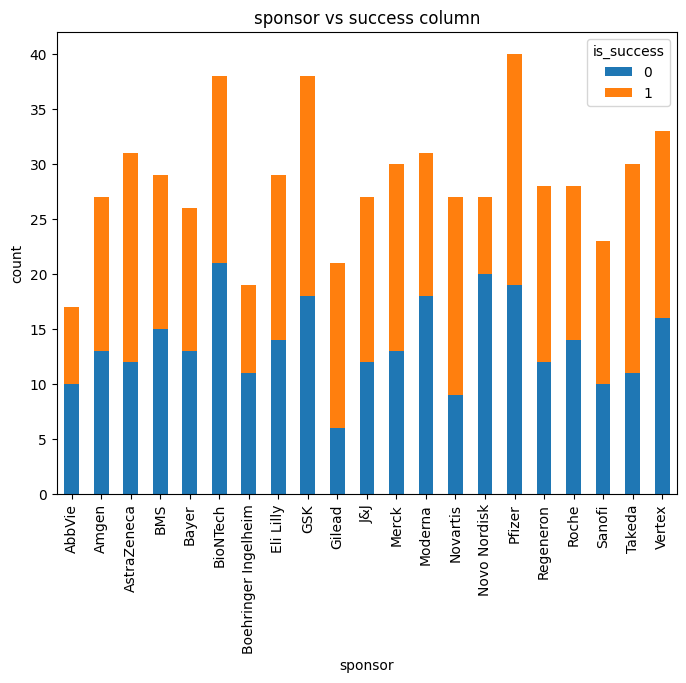

In [25]:
ct=pd.crosstab(df['sponsor'],df['is_success'])
ct.plot(kind="bar",stacked=True,figsize=(8,6))
plt.title("sponsor vs success column")
plt.ylabel("count")
plt.show()

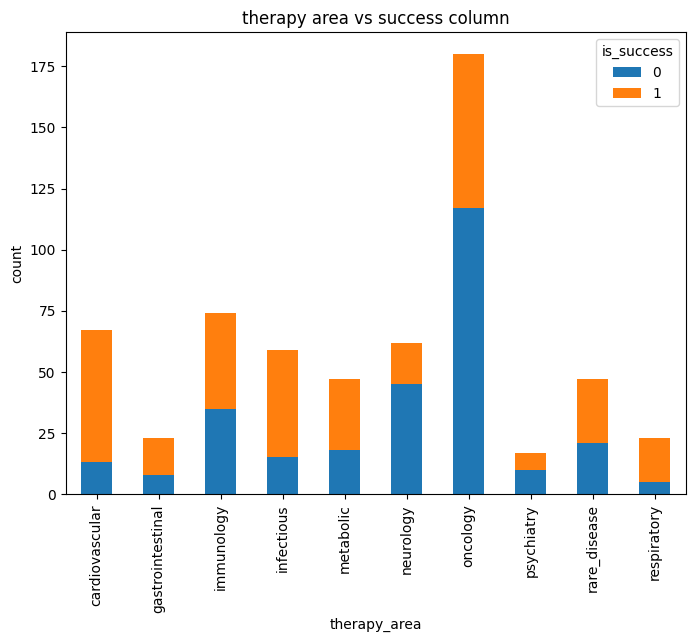

In [26]:
ct=pd.crosstab(df['therapy_area'],df['is_success'])
ct.plot(kind="bar",stacked=True,figsize=(8,6))
plt.title("therapy area vs success column")
plt.ylabel("count")
plt.show()

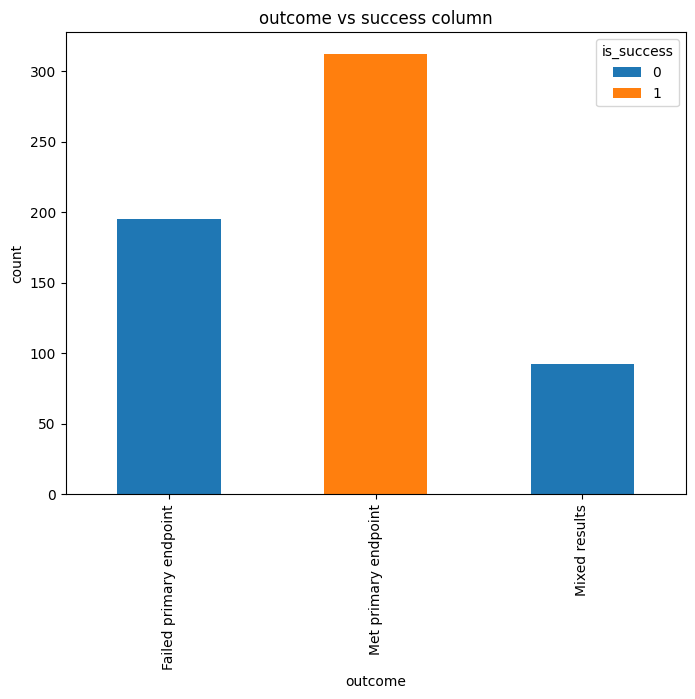

In [27]:
ct=pd.crosstab(df['outcome'],df['is_success'])
ct.plot(kind='bar',stacked=True,figsize=(8,6))
plt.title("outcome vs success column")
plt.ylabel("count")
plt.show()